# Lab 6 – Filtering in the Frequency Domain
## Task #1: Sobel Filter Applied in the Frequency Domain
**Course:** ARTI404 – Image Processing

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize
from numpy.fft import fft2, ifft2, fftshift, ifftshift

### Step 1 – Load and resize the Cameraman image

In [4]:
# Load cameraman image (already grayscale)
image = data.camera()
image = resize(image, (256, 256), anti_aliasing=True)  # Resize for faster FFT

M, N = image.shape
print(f"Image shape: {M} x {N}")

Image shape: 256 x 256


### Step 2 – Define the Sobel kernels

In [5]:
# Sobel filters (detect horizontal and vertical edges)
sobel_x = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]], dtype=float)  # Detects vertical edges

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=float)  # Detects horizontal edges

### Step 3 – Embed kernel in image-size canvas and take its FFT

To multiply in the frequency domain, the kernel must be the **same size** as the image.
We center it in a zero-padded canvas and use `ifftshift` before `fft2` so that the
DC component (kernel origin) is correctly placed at position (0, 0).

In [6]:
def center_embed_kernel(kernel, shape):
    """
    Embed a small kernel centered in a zero-padded array of the given shape,
    then return its 2-D FFT (with correct origin placement via ifftshift).
    """
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape

    # Center coordinates of the padded canvas
    cy, cx = ph // 2, pw // 2

    # Insert kernel centered at the image center
    padded[cy - kh//2 : cy - kh//2 + kh,
           cx - kw//2 : cx - kw//2 + kw] = kernel

    # ifftshift moves (0,0) from center back to top-left before FFT
    return fft2(ifftshift(padded))

### Step 4 – Compute FFT of the image and filters

In [7]:
# FFT of the image
F = fft2(image)

# FFT of the centered Sobel filters
H_x = center_embed_kernel(sobel_x, (M, N))
H_y = center_embed_kernel(sobel_y, (M, N))

### Step 5 – Multiply in the frequency domain (convolution theorem)

In [8]:
# Filtering = element-wise multiplication in frequency domain
F_sobel_x = F * H_x
F_sobel_y = F * H_y

# Inverse FFT to get spatial results
sobel_x_result = np.real(ifft2(F_sobel_x))
sobel_y_result = np.real(ifft2(F_sobel_y))

# Combined Sobel magnitude
sobel_magnitude = np.sqrt(sobel_x_result**2 + sobel_y_result**2)

### Step 6 – Plot all results

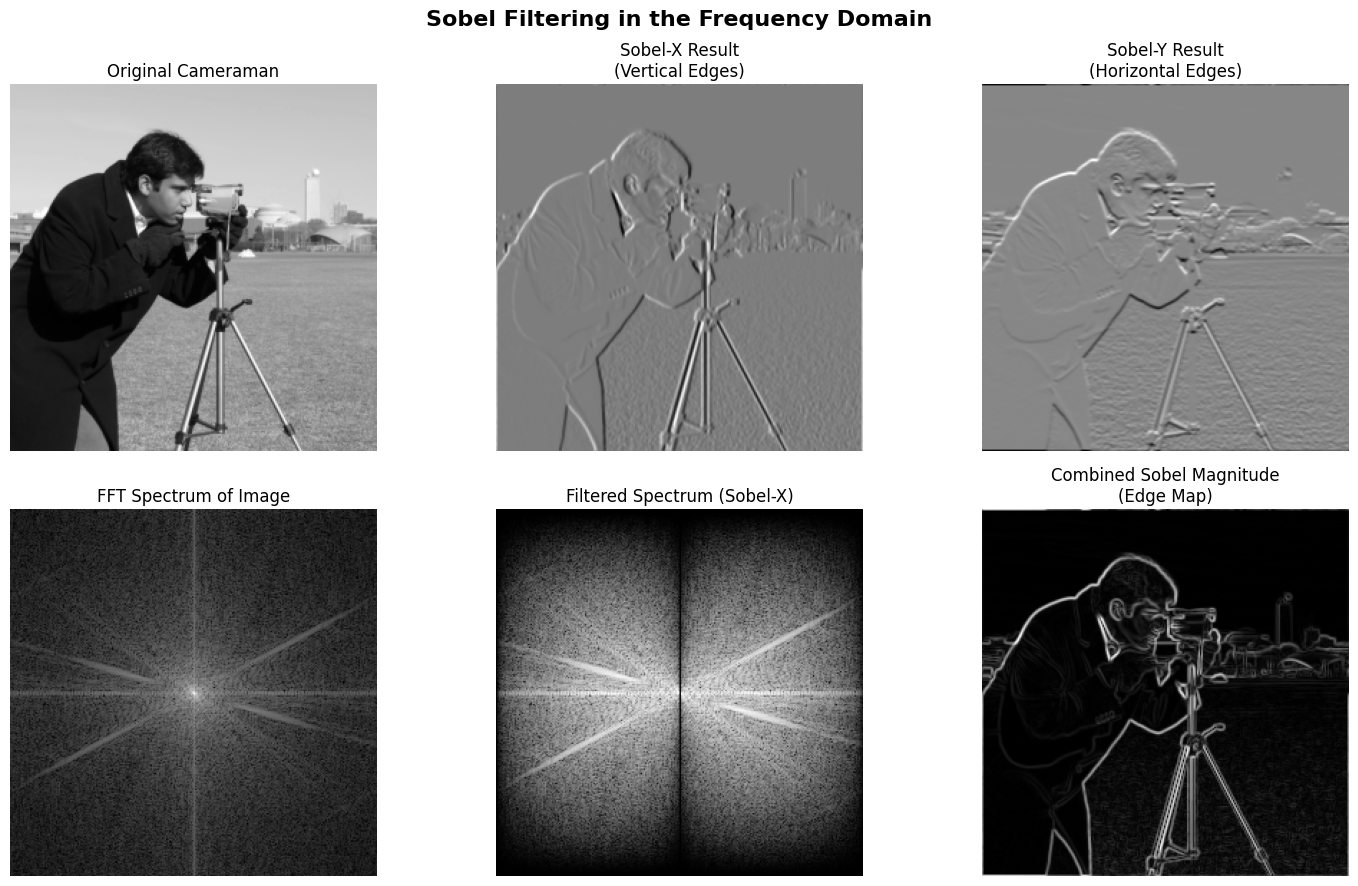

Figure saved as sobel_frequency_domain.png


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Sobel Filtering in the Frequency Domain', fontsize=16, fontweight='bold')

# Row 1: Spatial results
axes[0, 0].imshow(image, cmap='gray')
axes[0, 0].set_title('Original Cameraman')
axes[0, 0].axis('off')

axes[0, 1].imshow(sobel_x_result, cmap='gray')
axes[0, 1].set_title('Sobel-X Result\n(Vertical Edges)')
axes[0, 1].axis('off')

axes[0, 2].imshow(sobel_y_result, cmap='gray')
axes[0, 2].set_title('Sobel-Y Result\n(Horizontal Edges)')
axes[0, 2].axis('off')

# Row 2: Frequency spectra
axes[1, 0].imshow(np.log(1 + np.abs(fftshift(F))), cmap='gray')
axes[1, 0].set_title('FFT Spectrum of Image')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.log(1 + np.abs(fftshift(F_sobel_x))), cmap='gray')
axes[1, 1].set_title('Filtered Spectrum (Sobel-X)')
axes[1, 1].axis('off')

axes[1, 2].imshow(sobel_magnitude, cmap='gray')
axes[1, 2].set_title('Combined Sobel Magnitude\n(Edge Map)')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('sobel_frequency_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved as sobel_frequency_domain.png')